## 📚 Step 0: Import libraries

Load core libraries for data handling, modelling, and visualisation.

In [5]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Step 1: Load dataset

Import the dataset and standardise column names for consistency.

In [6]:
# Load dataset
df = pd.read_csv('site_leaching_data.csv')
df_jun = pd.read_csv('site_leaching_data_jun_25.csv')
df_train = pd.read_csv('site_leaching_data_jun_25.csv')

# Ensure datetime is parsed
df["Date"] = pd.to_datetime(df["Date"])
df_train["Date"] = pd.to_datetime(df_train["Date"])
df_jun["Date"] = pd.to_datetime(df_jun["Date"])

# Create subsets of the latest data
df_train = df_train[(df_train["Date"] >= "2025-01-01") & (df_train["Date"] <= "2025-04-30")]
df_jun = df_jun[df_jun["Date"] >= "2025-05-01"]

## ⚙️ Step 2: Define constants

Set plant configuration, material properties, modelling parameters, and economic assumptions.

## 📊 Step 3: Define plotting helpers

In [7]:
# Create a parity plot
def comparison_scatter_ideal_line(df, x_col, y_col, xlabel, ylabel, title,
                                  fig_size=(6, 6), title_fontsize=16,
                xbounds=None, ybounds=None,
                alpha=0.6, ideal_line_color='red', ideal_line_style='--'):
    """
    Create a scatter plot with an ideal line (y=x) for comparison.
    Parameters:
    - df: DataFrame containing the data.
    - x_col: Column name for x-axis data.
    - y_col: Column name for y-axis data.
    - xlabel: Label for x-axis.
    - ylabel: Label for y-axis.
    - title: Title of the plot.
    - fig_size: Size of the figure.
    - title_fontsize: Font size for the title.
    - xbounds: Optional bounds for x-axis.
    - ybounds: Optional bounds for y-axis.
    - alpha: Transparency level for the scatter points.
    - ideal_line_color: Color of the ideal line.
    - ideal_line_style: Style of the ideal line (e.g., '--', '-.', etc.).
    """

    if not xbounds: xbounds=[df[x_col].min(), df[x_col].max()]
    if not ybounds: ybounds=[df[y_col].min(), df[y_col].max()]
    plt.figure(figsize=fig_size)
    sns.set_theme(style="whitegrid")
    sns.scatterplot(x=x_col, y=y_col, data=df, alpha=alpha)
    plt.plot(xbounds, ybounds,
             color=ideal_line_color, linestyle=ideal_line_style, label='Ideal')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title, fontsize=title_fontsize)
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

✅ Fitted kinetic params: k_base=5.7833e-03, CN_exp=-7.950, DO_exp=1.825
📉 Mean residual bias: 87.85 percentage points

📈 Residual Model Performance:
  R²: 0.742
  MAE: 0.838 % recovery
  RMSE: 1.060


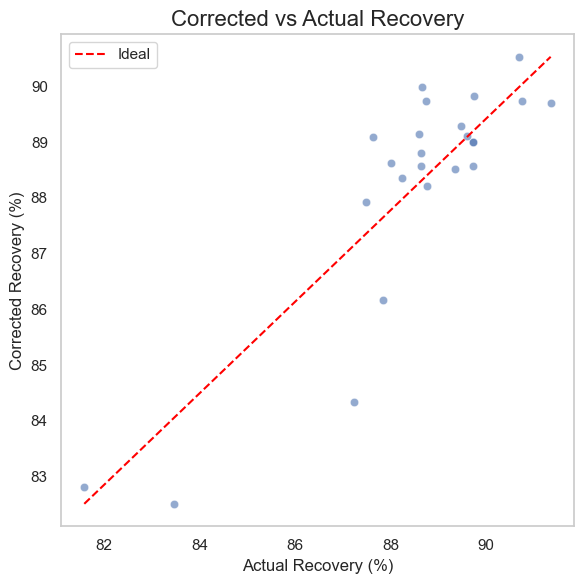

In [10]:
# ---------------------------------------------
# STEP 1: Kinetic Model Fitting
# ---------------------------------------------

def fit_kinetic_parameters(df):
    def objective(params, df):
        k_base, cn_exp, do_exp = params
        cn = df['CN_Concentration_PL_01'].clip(lower=1)
        do = df['Dissolved_Oxygen_PL_01'].clip(lower=0.1)
        grade = df['Au_Grade']
        liberation = df['Gold_Liberation']
        kinetic_recovery = (1 - (1 - liberation) * np.exp(-k_base * cn**cn_exp * do**do_exp)) * 100
        return np.mean(np.abs(kinetic_recovery - df['Au_Recovery_pct']))

    initial_guess = [0.001, 0.5, 0.5]
    result = minimize(objective, initial_guess, args=(df,), method='Nelder-Mead')

    if result.success:
        k_base, cn_exp, do_exp = result.x
        print(f"✅ Fitted kinetic params: k_base={k_base:.4e}, "
              f"CN_exp={cn_exp:.3f}, DO_exp={do_exp:.3f}")
        return k_base, cn_exp, do_exp
    else:
        raise RuntimeError("Kinetic parameter fitting failed.")

def apply_kinetic_model(df, k_base, cn_exp, do_exp):
    cn = df['CN_Concentration_PL_01'].clip(lower=1)
    do = df['Dissolved_Oxygen_PL_01'].clip(lower=0.1)
    grade = df['Au_Grade']
    liberation = df['Gold_Liberation']

    # Recovery models
    kinetic_pct = 100 * liberation * (1 - np.exp(-k_base * cn**cn_exp * do**do_exp))
    kinetic_grams = grade * (kinetic_pct / 100)

    df['Kinetic_Recovery_pct'] = kinetic_pct
    df['Kinetic_Au_Recovery'] = kinetic_grams
    return df

# ---------------------------------------------
# STEP 2: Residual Learning
# ---------------------------------------------

def residual_model_training(df, features):
    df['Smoothed_Residual'] = df['Au_Recovery_pct'] - df['Kinetic_Recovery_pct']
    mean_bias = df['Smoothed_Residual'].mean()
    df['Centered_Residual'] = df['Smoothed_Residual'] - mean_bias
    print(f"📉 Mean residual bias: {mean_bias:.2f} percentage points")

    X = df[features]
    y = df['Centered_Residual']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    model.fit(X_train, y_train)

    test_df = X_test.copy()
    test_df['Centered_Predicted_Residual'] = model.predict(X_test)
    test_df['Corrected_Recovery'] = df.loc[X_test.index, 'Kinetic_Recovery_pct'] + \
                                    test_df['Centered_Predicted_Residual'] + mean_bias
    test_df['Actual_Recovery'] = df.loc[X_test.index, 'Au_Recovery_pct']

    r2 = r2_score(test_df['Actual_Recovery'], test_df['Corrected_Recovery'])
    mae = mean_absolute_error(test_df['Actual_Recovery'], test_df['Corrected_Recovery'])
    rmse = root_mean_squared_error(test_df['Actual_Recovery'], test_df['Corrected_Recovery'])
    print(f"\n📈 Residual Model Performance:\n  R²: {r2:.3f}\n  MAE: {mae:.3f} %"
          f" recovery\n  RMSE: {rmse:.3f}")

    return model, test_df

# ---------------------------------------------
# RUN PIPELINE
# ---------------------------------------------

# Make sure df_eval exists
df = df_train.copy()

# Step 2: Add time-based feature
df['Month'] = pd.to_datetime(df['Date']).dt.month

# Interaction and nonlinear terms
df["CNxDO"] = df["CN_Concentration_PL_01"] * df["Dissolved_Oxygen_PL_01"]
df["Grade_x_Fines_Sqrt"] = np.sqrt(df["Grade_x_Fines"])
df['Gold_Liberation'] = np.clip(df['Grade_x_Fines_Sqrt'], 0, 1)

# Fit and apply kinetic model
k_base, cn_exp, do_exp = fit_kinetic_parameters(df)
df = apply_kinetic_model(df, k_base, cn_exp, do_exp)

# Step 0.1: Compute actual - kinetic residuals
df['Recovery_Residual'] = df['Au_Recovery_pct'] - df['Kinetic_Au_Recovery']

# Step 1: Smooth residuals
df['Smoothed_Residual'] = df['Recovery_Residual'].rolling(window=7, min_periods=1).mean()

# Residual model training
features = [
    'Leach_Feed_Throughput_M3Hr',
    'Percentsolids',
    'Grade_x_Fines_Sqrt',
    'Dissolved_Oxygen_PL_01',
    'CNxDO',
    'Particle_Size'
]
residual_model, results_df = residual_model_training(df, features)

# Visualise

comparison_scatter_ideal_line(
    results_df, 'Actual_Recovery', 'Corrected_Recovery',
    xlabel="Actual Recovery (%)",
    ylabel="Corrected Recovery (%)",
    title="Corrected vs Actual Recovery",
    fig_size=(6, 6)
)

In [11]:
df.columns.to_list()

['Date',
 'Leach_Feed_Throughput_M3Hr',
 'Leach_Feed_Throughput_M3Day',
 'Percentsolids',
 'Leach_Feed_Grade_Au_Gt_Ds',
 'Leach_Feed_Grade_Au_Gt_Ns',
 'Au_Grade',
 'Leach_Feed_Grade_Ag_Gt_Ds',
 'Leach_Feed_Grade_Ag_Gt_Ns',
 'Leach_Feed_Grade_Ag_Gt_Day',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_1',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_2',
 'Daily_Nacn_Consumption_Kgt',
 'Mtd_Nacn_Consumption_Kgt',
 'Nacn_Used_T',
 'Au_Feed_g',
 'CN_Tailings_Concentration',
 'Au_Tailings_g',
 'Leach_Feed_Gt_150um_Day',
 'Leach_Feed_Gt_75um_Day',
 'Leach_Feed_Lt_75um_Day',
 'Cyanide_Profile_Ppm_Leach_Tank_1',
 'Cyanide_Profile_Ppm_Leach_Tank_2',
 'Cyanide_Profile_Ppm_Cil_Tank_01',
 'Cyanide_Profile_Ppm_Cil_Tank_02',
 'Cyanide_Profile_Ppm_Cil_Tank_03',
 'Cyanide_Profile_Ppm_Cil_Tank_04',
 'Cyanide_Profile_Ppm_Cil_Tank_05',
 'Cyanide_Profile_Ppm_Cil_Tank_06',
 'Cyanide_Profile_Ppm_Cil_Tank_07',
 'Cyanide_Profile_Ppm_Cil_Tank_08',
 'Cyanide_Profile_Ppm_Cil_Tank_09',
 'Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01',
 'Dis